### Cell 1: Setup and imports

In [1]:
import pandas as pd
import numpy as np
import pickle
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.preprocessing import StandardScaler

# Paths
DATA_DIR = Path('../data/processed')
RESULTS_DIR = Path('../results')
TABLES_DIR = RESULTS_DIR / 'tables'
MODELS_DIR = RESULTS_DIR / 'models'
TABLES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
N_CV_FOLDS = 5

### Cell 2: Load data and the canonical split

In [2]:
# Load the permissive-cleaned dataset
df = pd.read_csv(DATA_DIR / 'metabric_permissive.csv')
df_encoded = pd.read_csv(DATA_DIR / 'metabric_permissive_encoded.csv')

# Load the canonical train/test split
splits = pd.read_csv(DATA_DIR / 'split_indices.csv')
train_idx = splits['permissive_train'].dropna().astype(int).values
test_idx = splits['permissive_test'].dropna().astype(int).values

print(f"Permissive (tidy): {df.shape}")
print(f"Permissive (encoded): {df_encoded.shape}")
print(f"Train: {len(train_idx)} patients, Test: {len(test_idx)} patients")

# Map the target
df['target'] = df['Relapse Free Status'].map({'Not Recurred': 0, 'Recurred': 1})

# Verify class balance
print(f"\nClass balance:")
print(f"  Train: {df.iloc[train_idx]['target'].mean():.3f} recurred")
print(f"  Test:  {df.iloc[test_idx]['target'].mean():.3f} recurred")

Permissive (tidy): (1970, 19)
Permissive (encoded): (1970, 40)
Train: 1576 patients, Test: 394 patients

Class balance:
  Train: 0.406 recurred
  Test:  0.406 recurred


### Cell 3: Helper function for consistent metric reporting

In [3]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name, 
                   notes="", cv=True):
    """
    Train, predict, and return a dict of metrics.
    Reports both CV (on train) and held-out test set metrics.
    """
    # Fit on train
    model.fit(X_train, y_train)
    
    # Test set predictions
    y_pred = model.predict(X_test)
    
    metrics = {
        'model': model_name,
        'notes': notes,
        'n_train': len(X_train),
        'n_test': len(X_test),
        'test_accuracy': accuracy_score(y_test, y_pred),
        'test_precision_recurrence': precision_score(y_test, y_pred, pos_label=1, zero_division=0),
        'test_recall_recurrence': recall_score(y_test, y_pred, pos_label=1, zero_division=0),
        'test_f1_recurrence': f1_score(y_test, y_pred, pos_label=1, zero_division=0),
    }
    
    # Confusion matrix breakdown
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    metrics.update({
        'test_true_neg': tn, 'test_false_pos': fp,
        'test_false_neg': fn, 'test_true_pos': tp,
    })
    
    # CV on training set
    if cv:
        cv_splitter = StratifiedKFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
        cv_acc = cross_val_score(model, X_train, y_train, cv=cv_splitter, scoring='accuracy')
        cv_recall = cross_val_score(model, X_train, y_train, cv=cv_splitter, scoring='recall')
        metrics['cv_accuracy_mean'] = cv_acc.mean()
        metrics['cv_accuracy_std'] = cv_acc.std()
        metrics['cv_recall_mean'] = cv_recall.mean()
        metrics['cv_recall_std'] = cv_recall.std()
    
    return metrics, y_pred


def print_metrics(metrics):
    print(f"\n{'='*60}")
    print(f"  {metrics['model']}")
    if metrics['notes']:
        print(f"  ({metrics['notes']})")
    print('='*60)
    print(f"  Train: {metrics['n_train']}, Test: {metrics['n_test']}")
    if 'cv_accuracy_mean' in metrics:
        print(f"  CV accuracy (5-fold):  "
              f"{metrics['cv_accuracy_mean']:.3f} ± {metrics['cv_accuracy_std']:.3f}")
        print(f"  CV recall (5-fold):    "
              f"{metrics['cv_recall_mean']:.3f} ± {metrics['cv_recall_std']:.3f}")
    print(f"  Test accuracy:           {metrics['test_accuracy']:.3f}")
    print(f"  Test recall (recurrence): {metrics['test_recall_recurrence']:.3f}")
    print(f"  Test precision (recurrence): {metrics['test_precision_recurrence']:.3f}")
    print(f"  Test F1 (recurrence):     {metrics['test_f1_recurrence']:.3f}")
    print(f"  Confusion: TN={metrics['test_true_neg']}, FP={metrics['test_false_pos']}, "
          f"FN={metrics['test_false_neg']}, TP={metrics['test_true_pos']}")


all_results = []

### Cell 4: Chapter-faithful baseline

In [4]:
# === Chapter-faithful baseline ===
# Chapter's six features INCLUDING the leaky one.
# Approach: use the already-imputed permissive features for the 5 non-leaky ones,
# recover the leaky feature from raw data and median-impute its missingness.

# Recover the leaky feature aligned to our 1,970-patient permissive cohort
raw_df = pd.read_csv('../data/raw/metabric.csv')
raw_predictors_chapter = raw_df.drop(columns=[
    'Patient ID', 'Cohort', 'Sex', 'Cancer Type',
    'Cancer Type Detailed', 'ER status measured by IHC',
    'HER2 status measured by SNP6', '3-Gene classifier subtype',
    'Oncotree Code', 'Integrative Cluster',
    'TNBC', 'NPI-Prognosis', 'Age40', 'S-Tumor-Size',
    'Survival Status', 'RecurredNotRecurredStatus',
    'Overall Survival (Months)', 'Overall Survival Status',
    "Patient's Vital Status", 'Tumor Stage',
    # NOTE: NOT dropping 'Relapse Free Status (Months)' here — that's the leaky feature we want
])

# Apply same universal exclusions
mts_mask = raw_predictors_chapter['Chemotherapy'].isna()
sarc_mask = raw_df['Cancer Type'] == 'Breast Sarcoma'
target_mask = raw_predictors_chapter['Relapse Free Status'].isna()
nc_mask = raw_predictors_chapter['Pam50 + Claudin-low subtype'] == 'NC'
to_drop_chapter = mts_mask | sarc_mask | target_mask | nc_mask

raw_aligned = raw_predictors_chapter[~to_drop_chapter].reset_index(drop=True)
assert len(raw_aligned) == 1970, f"Expected 1,970, got {len(raw_aligned)}"

# Build the chapter-faithful feature matrix:
# - Use the already-imputed values from df_permissive for the 5 standard features
# - Pull and impute the leaky feature from raw_aligned
chapter_features_no_leak = ['ER Status', 'PR Status', 'Radio Therapy',
                             'Tumor Size(mm)', 'Pam50 + Claudin-low subtype']

X_chapter = pd.get_dummies(
    df[chapter_features_no_leak].copy(),
    columns=['ER Status', 'PR Status', 'Radio Therapy', 'Pam50 + Claudin-low subtype'],
    drop_first=True,
).astype(float)

# Add the leaky feature, median-imputed
leaky = raw_aligned['Relapse Free Status (Months)'].copy()
leaky_median = leaky.median()
leaky = leaky.fillna(leaky_median)
X_chapter['Relapse Free Status (Months)'] = leaky.values

# Verify no NaN remains
assert X_chapter.isna().sum().sum() == 0, "X_chapter still has NaN"
print(f"X_chapter shape: {X_chapter.shape}, NaN count: {X_chapter.isna().sum().sum()}")

y_chapter = df['target']

X_chapter_train = X_chapter.iloc[train_idx]
X_chapter_test = X_chapter.iloc[test_idx]
y_chapter_train = y_chapter.iloc[train_idx]
y_chapter_test = y_chapter.iloc[test_idx]

# Chapter's hyperparameters
gbm_chapter = GradientBoostingClassifier(
    learning_rate=0.01, max_depth=3, n_estimators=200, random_state=RANDOM_STATE,
)

metrics, _ = evaluate_model(
    gbm_chapter, X_chapter_train, y_chapter_train,
    X_chapter_test, y_chapter_test,
    model_name="GBM (chapter-faithful)",
    notes="Chapter's 6 features INCLUDING leaky 'Relapse Free Status (Months)'",
)
print_metrics(metrics)
all_results.append(metrics)

X_chapter shape: (1970, 10), NaN count: 0

  GBM (chapter-faithful)
  (Chapter's 6 features INCLUDING leaky 'Relapse Free Status (Months)')
  Train: 1576, Test: 394
  CV accuracy (5-fold):  0.783 ± 0.021
  CV recall (5-fold):    0.634 ± 0.039
  Test accuracy:           0.769
  Test recall (recurrence): 0.631
  Test precision (recurrence): 0.759
  Test F1 (recurrence):     0.689
  Confusion: TN=202, FP=32, FN=59, TP=101


### Cell 5: Canonical baseline (no leaky feature)
This is the comparison anchor every NSAI method will be measured against.

In [5]:
# === Canonical (honest) baseline ===
# Chapter's six features MINUS the leaky one.

# Use the permissive-cleaned data (which already has the leaky feature dropped)
canonical_features = [
    'ER Status', 'PR Status', 'Radio Therapy',
    'Tumor Size(mm)', 'Pam50 + Claudin-low subtype',
]

X_canonical = pd.get_dummies(
    df[canonical_features].copy(),
    columns=['ER Status', 'PR Status', 'Radio Therapy', 'Pam50 + Claudin-low subtype'],
    drop_first=True,
).astype(float)

y_canonical = df['target']

X_canonical_train = X_canonical.iloc[train_idx]
X_canonical_test = X_canonical.iloc[test_idx]
y_canonical_train = y_canonical.iloc[train_idx]
y_canonical_test = y_canonical.iloc[test_idx]

gbm_canonical = GradientBoostingClassifier(
    learning_rate=0.01, max_depth=3, n_estimators=200, random_state=RANDOM_STATE,
)

metrics, _ = evaluate_model(
    gbm_canonical, X_canonical_train, y_canonical_train,
    X_canonical_test, y_canonical_test,
    model_name="GBM (canonical baseline)",
    notes="Chapter's 6 features WITHOUT leaky feature — comparison anchor",
)
print_metrics(metrics)
all_results.append(metrics)

# Save this trained model as a pickle — SHAP and mimic trees will load it
with open(MODELS_DIR / 'canonical_gbm.pkl', 'wb') as f:
    pickle.dump({
        'model': gbm_canonical,
        'features': X_canonical.columns.tolist(),
        'train_idx': train_idx,
        'test_idx': test_idx,
    }, f)
print("\nSaved canonical GBM to results/models/canonical_gbm.pkl")


  GBM (canonical baseline)
  (Chapter's 6 features WITHOUT leaky feature — comparison anchor)
  Train: 1576, Test: 394
  CV accuracy (5-fold):  0.612 ± 0.014
  CV recall (5-fold):    0.270 ± 0.048
  Test accuracy:           0.609
  Test recall (recurrence): 0.250
  Test precision (recurrence): 0.541
  Test F1 (recurrence):     0.342
  Confusion: TN=200, FP=34, FN=120, TP=40

Saved canonical GBM to results/models/canonical_gbm.pkl


### Cell 6: Full-feature variant baselines

In [6]:
# === Variant: Full 18-feature predictor set ===
# Use the encoded variant directly

X_full = df_encoded.drop(columns=['Relapse Free Status']).astype(float)
y_full = df_encoded['Relapse Free Status'].astype(int)

X_full_train = X_full.iloc[train_idx]
X_full_test = X_full.iloc[test_idx]
y_full_train = y_full.iloc[train_idx]
y_full_test = y_full.iloc[test_idx]

# GBM on full feature set, chapter's hyperparameters
gbm_full = GradientBoostingClassifier(
    learning_rate=0.01, max_depth=3, n_estimators=200, random_state=RANDOM_STATE,
)
metrics, _ = evaluate_model(
    gbm_full, X_full_train, y_full_train, X_full_test, y_full_test,
    model_name="GBM (full features)",
    notes="All 18 predictors, chapter's hyperparameters",
)
print_metrics(metrics)
all_results.append(metrics)

# Logistic regression on full feature set
lr_full = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
metrics, _ = evaluate_model(
    lr_full, X_full_train, y_full_train, X_full_test, y_full_test,
    model_name="Logistic Regression (full features)",
    notes="All 18 predictors, default hyperparameters",
)
print_metrics(metrics)
all_results.append(metrics)

# Logistic regression on chapter's 6 features
lr_canonical = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
metrics, _ = evaluate_model(
    lr_canonical, X_canonical_train, y_canonical_train, X_canonical_test, y_canonical_test,
    model_name="Logistic Regression (canonical)",
    notes="Chapter's 6 features (no leaky), default hyperparameters",
)
print_metrics(metrics)
all_results.append(metrics)


  GBM (full features)
  (All 18 predictors, chapter's hyperparameters)
  Train: 1576, Test: 394
  CV accuracy (5-fold):  0.640 ± 0.029
  CV recall (5-fold):    0.305 ± 0.028
  Test accuracy:           0.665
  Test recall (recurrence): 0.344
  Test precision (recurrence): 0.671
  Test F1 (recurrence):     0.455
  Confusion: TN=207, FP=27, FN=105, TP=55

  Logistic Regression (full features)
  (All 18 predictors, default hyperparameters)
  Train: 1576, Test: 394
  CV accuracy (5-fold):  0.654 ± 0.017
  CV recall (5-fold):    0.345 ± 0.045
  Test accuracy:           0.662
  Test recall (recurrence): 0.319
  Test precision (recurrence): 0.680
  Test F1 (recurrence):     0.434
  Confusion: TN=210, FP=24, FN=109, TP=51

  Logistic Regression (canonical)
  (Chapter's 6 features (no leaky), default hyperparameters)
  Train: 1576, Test: 394
  CV accuracy (5-fold):  0.611 ± 0.023
  CV recall (5-fold):    0.241 ± 0.038
  Test accuracy:           0.602
  Test recall (recurrence): 0.219
  Test pre

In [7]:
# === Update canonical GBM pickle ===
# Originally saved the chapter's-6-feature GBM as canonical.
# After Phase 2 results showed the full-feature GBM is the stronger honest baseline,
# we update what gets saved as canonical and keep the 6-feature version separately.

# The full-features GBM was trained earlier in Cell 6 as gbm_full.
# Save it as canonical (overwrite the previous pickle).
with open(MODELS_DIR / 'canonical_gbm.pkl', 'wb') as f:
    pickle.dump({
        'model': gbm_full,
        'features': X_full.columns.tolist(),
        'train_idx': train_idx,
        'test_idx': test_idx,
        'description': 'Full 18-feature GBM, chapter hyperparameters. Canonical comparison anchor for NSAI methods.',
    }, f)
print("Saved canonical GBM (full features) to results/models/canonical_gbm.pkl")

# Also save the chapter's 6-feature GBM as a separate reference
with open(MODELS_DIR / 'chapter_gbm.pkl', 'wb') as f:
    pickle.dump({
        'model': gbm_canonical,
        'features': X_canonical.columns.tolist(),
        'train_idx': train_idx,
        'test_idx': test_idx,
        'description': "Chapter's 6 features, no outcome-adjacent feature. Secondary comparison point.",
    }, f)
print("Saved chapter GBM (6 features) to results/models/chapter_gbm.pkl")

Saved canonical GBM (full features) to results/models/canonical_gbm.pkl
Saved chapter GBM (6 features) to results/models/chapter_gbm.pkl


### Cell 7: Recall-tuned GBM variants

In [8]:
# === Recall-tuned variants ===
# Two approaches: class weighting (built-in) and threshold tuning (post-hoc)

# Note: GradientBoostingClassifier doesn't have class_weight, so we use 
# sample_weight via GridSearchCV with scoring='recall'

# Recall-tuned via grid search on hyperparameters
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 5],
    'n_estimators': [100, 200, 300],
}
gbm_recall = GridSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    scoring='recall',  # tune for recall on the recurrence class
    cv=N_CV_FOLDS,
    n_jobs=-1,
)
gbm_recall.fit(X_full_train, y_full_train)
print(f"Best params (recall-tuned, full features): {gbm_recall.best_params_}")
print(f"Best CV recall: {gbm_recall.best_score_:.3f}")

best_gbm = gbm_recall.best_estimator_
metrics, _ = evaluate_model(
    best_gbm, X_full_train, y_full_train, X_full_test, y_full_test,
    model_name="GBM (recall-tuned, full features)",
    notes=f"GridSearchCV on recall, best={gbm_recall.best_params_}",
    cv=False,  # already did CV in grid search
)
# Add CV recall back manually
metrics['cv_recall_mean'] = gbm_recall.best_score_
metrics['cv_recall_std'] = gbm_recall.cv_results_['std_test_score'][gbm_recall.best_index_]
print_metrics(metrics)
all_results.append(metrics)

Best params (recall-tuned, full features): {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best CV recall: 0.436

  GBM (recall-tuned, full features)
  (GridSearchCV on recall, best={'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200})
  Train: 1576, Test: 394
  Test accuracy:           0.602
  Test recall (recurrence): 0.394
  Test precision (recurrence): 0.512
  Test F1 (recurrence):     0.445
  Confusion: TN=174, FP=60, FN=97, TP=63


### Cell 8: Reproducibility investigation
This is the targeted attempt to get close to the chapter's 85.9%.

In [9]:
# === Reproducibility investigation ===
# Multiple attempts at the chapter's setup with different choices to see
# what gets us closest to 85.9%

print("="*60)
print("  REPRODUCIBILITY INVESTIGATION")
print("="*60)
print("Trying different setups to see what produces the chapter's reported 85.9%.")
print()

repro_results = []

# Attempt 1: Different random seeds (chapter's setup, 5 different splits)
from sklearn.model_selection import train_test_split as tts

print("Attempt 1: Chapter setup, 5 different random seeds")
seed_accuracies = []
for seed in [0, 1, 7, 42, 123]:
    X_tr, X_te, y_tr, y_te = tts(
        X_chapter, y_chapter, test_size=0.2, stratify=y_chapter, random_state=seed
    )
    m = GradientBoostingClassifier(
        learning_rate=0.01, max_depth=3, n_estimators=200, random_state=RANDOM_STATE
    )
    m.fit(X_tr, y_tr)
    acc = m.score(X_te, y_te)
    seed_accuracies.append(acc)
    print(f"  seed={seed}: test_acc={acc:.3f}")

print(f"  Mean across seeds: {np.mean(seed_accuracies):.3f} ± {np.std(seed_accuracies):.3f}")
print(f"  Max: {max(seed_accuracies):.3f}")
repro_results.append({
    'attempt': 'Chapter setup, 5 seeds',
    'mean_acc': np.mean(seed_accuracies),
    'max_acc': max(seed_accuracies),
})
print()

# Attempt 2: Strict-cleaned data with chapter features (including leaky)
print("Attempt 2: Strict-cleaned data, chapter features + leaky")

df_strict = pd.read_csv(DATA_DIR / 'metabric_strict.csv')
df_strict['target'] = df_strict['Relapse Free Status'].map({'Not Recurred': 0, 'Recurred': 1})

# Recover leaky feature from raw, aligned to strict cohort
# Strict cohort = universal drops + listwise drop of any remaining missingness
# We can identify it by row-matching — but simpler: just recompute strict from raw
raw_strict_predictors = raw_predictors_chapter[~to_drop_chapter].reset_index(drop=True)
# Listwise-drop on the standard predictor columns (not leaky)
predictor_cols_no_leak = [c for c in raw_strict_predictors.columns 
                          if c not in ['Relapse Free Status', 'Relapse Free Status (Months)']]
strict_mask = raw_strict_predictors[predictor_cols_no_leak].notna().all(axis=1)
raw_strict = raw_strict_predictors[strict_mask].reset_index(drop=True)
print(f"  Reconstructed strict cohort: {len(raw_strict)} rows")

# Should match df_strict's length (1,603)
assert len(raw_strict) == len(df_strict), f"Strict mismatch: {len(raw_strict)} vs {len(df_strict)}"

X_strict_chapter = pd.get_dummies(
    raw_strict[chapter_features_no_leak].copy(),
    columns=['ER Status', 'PR Status', 'Radio Therapy', 'Pam50 + Claudin-low subtype'],
    drop_first=True,
).astype(float)
# Add leaky feature with median imputation
leaky_strict = raw_strict['Relapse Free Status (Months)'].fillna(
    raw_strict['Relapse Free Status (Months)'].median()
)
X_strict_chapter['Relapse Free Status (Months)'] = leaky_strict.values

y_strict_chapter = raw_strict['Relapse Free Status'].map({'Not Recurred': 0, 'Recurred': 1})

# Use the strict split indices
strict_train_idx = splits['strict_train'].dropna().astype(int).values
strict_test_idx = splits['strict_test'].dropna().astype(int).values

X_tr = X_strict_chapter.iloc[strict_train_idx]
X_te = X_strict_chapter.iloc[strict_test_idx]
y_tr = y_strict_chapter.iloc[strict_train_idx]
y_te = y_strict_chapter.iloc[strict_test_idx]

m = GradientBoostingClassifier(
    learning_rate=0.01, max_depth=3, n_estimators=200, random_state=RANDOM_STATE
)
m.fit(X_tr, y_tr)
acc = m.score(X_te, y_te)
print(f"  Strict + chapter features + leaky: test_acc={acc:.3f}")
repro_results.append({'attempt': 'Strict + chapter features + leaky', 'mean_acc': acc, 'max_acc': acc})
print()


# Attempt 3: Try SMOTE on the canonical setup (chapter mentions Alva 2018 used SMOTE)
print("Attempt 3: SMOTE oversampling on chapter setup")
try:
    from imblearn.over_sampling import SMOTE
    smote = SMOTE(random_state=RANDOM_STATE)
    X_smote, y_smote = smote.fit_resample(X_chapter_train, y_chapter_train)
    m = GradientBoostingClassifier(
        learning_rate=0.01, max_depth=3, n_estimators=200, random_state=RANDOM_STATE
    )
    m.fit(X_smote, y_smote)
    acc = m.score(X_chapter_test, y_chapter_test)
    print(f"  SMOTE + chapter features + leaky: test_acc={acc:.3f}")
    repro_results.append({'attempt': 'SMOTE + chapter features + leaky', 'mean_acc': acc, 'max_acc': acc})
except ImportError:
    print("  imblearn not installed; skipping SMOTE attempt")
    repro_results.append({'attempt': 'SMOTE (not run)', 'mean_acc': None, 'max_acc': None})
print()

# Summary
print("="*60)
print("  REPRODUCIBILITY SUMMARY")
print("="*60)
print(f"Chapter reports: 0.859")
print(f"Best of our attempts:")
for r in repro_results:
    if r['max_acc'] is not None:
        gap = 0.859 - r['max_acc']
        print(f"  {r['attempt']}: {r['max_acc']:.3f} (gap to chapter: {gap:+.3f})")

  REPRODUCIBILITY INVESTIGATION
Trying different setups to see what produces the chapter's reported 85.9%.

Attempt 1: Chapter setup, 5 different random seeds
  seed=0: test_acc=0.769
  seed=1: test_acc=0.766
  seed=7: test_acc=0.787
  seed=42: test_acc=0.769
  seed=123: test_acc=0.792
  Mean across seeds: 0.777 ± 0.011
  Max: 0.792

Attempt 2: Strict-cleaned data, chapter features + leaky
  Reconstructed strict cohort: 1603 rows
  Strict + chapter features + leaky: test_acc=0.766

Attempt 3: SMOTE oversampling on chapter setup
  SMOTE + chapter features + leaky: test_acc=0.756

  REPRODUCIBILITY SUMMARY
Chapter reports: 0.859
Best of our attempts:
  Chapter setup, 5 seeds: 0.792 (gap to chapter: +0.067)
  Strict + chapter features + leaky: 0.766 (gap to chapter: +0.093)
  SMOTE + chapter features + leaky: 0.756 (gap to chapter: +0.103)


In [10]:
# === Reproducibility investigation, addendum: SMOTE check ===
# imblearn was not installed during the original cell 8 run.
# This cell tests whether SMOTE oversampling on the chapter's setup closes the gap.

print("="*60)
print("  REPRODUCIBILITY INVESTIGATION — SMOTE ADDENDUM")
print("="*60)
print("Testing whether SMOTE oversampling on the chapter's setup closes")
print("the persistent 7-9 point gap to the chapter's reported 0.859.")
print()

try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    print("imblearn not installed. Install with: pip install imbalanced-learn")
    print("Then rerun this cell.")
    raise

# Use the same chapter-faithful setup from cell 4: 
# X_chapter (chapter's 6 features including outcome-adjacent),
# y_chapter, train/test split.

# Try SMOTE at multiple seeds and on both the canonical 80/20 split
# and a few alternative splits, to see whether SMOTE specifically closes the gap.

smote_results = []

# Test 1: SMOTE on the canonical split, multiple SMOTE seeds
print("Test 1: SMOTE on canonical 80/20 split, varying SMOTE random seed")
for smote_seed in [0, 1, 7, 42, 123]:
    smote = SMOTE(random_state=smote_seed)
    X_smote, y_smote = smote.fit_resample(X_chapter_train, y_chapter_train)
    
    m = GradientBoostingClassifier(
        learning_rate=0.01, max_depth=3, n_estimators=200, random_state=RANDOM_STATE
    )
    m.fit(X_smote, y_smote)
    acc = m.score(X_chapter_test, y_chapter_test)
    print(f"  SMOTE seed={smote_seed}: test_acc={acc:.3f} "
          f"(SMOTE'd training: {len(X_smote)} samples vs {len(X_chapter_train)} original)")
    smote_results.append({'test': 'canonical_split', 'smote_seed': smote_seed, 
                          'split_seed': RANDOM_STATE, 'test_acc': acc})

# Test 2: SMOTE on multiple split seeds (combination of train/test variation and SMOTE)
print("\nTest 2: SMOTE on different train/test splits")
for split_seed in [0, 1, 7, 123]:
    X_tr, X_te, y_tr, y_te = tts(
        X_chapter, y_chapter, test_size=0.2, stratify=y_chapter, random_state=split_seed
    )
    smote = SMOTE(random_state=RANDOM_STATE)
    X_smote, y_smote = smote.fit_resample(X_tr, y_tr)
    
    m = GradientBoostingClassifier(
        learning_rate=0.01, max_depth=3, n_estimators=200, random_state=RANDOM_STATE
    )
    m.fit(X_smote, y_smote)
    acc = m.score(X_te, y_te)
    print(f"  split_seed={split_seed}: test_acc={acc:.3f}")
    smote_results.append({'test': 'split_variation', 'smote_seed': RANDOM_STATE,
                          'split_seed': split_seed, 'test_acc': acc})

# Test 3: SMOTE with strict cleaning + chapter features
print("\nTest 3: SMOTE on strict-cleaned data, chapter setup")
strict_train_idx = splits['strict_train'].dropna().astype(int).values
strict_test_idx = splits['strict_test'].dropna().astype(int).values

X_strict_chapter_train = X_strict_chapter.iloc[strict_train_idx]
X_strict_chapter_test = X_strict_chapter.iloc[strict_test_idx]
y_strict_chapter_train = y_strict_chapter.iloc[strict_train_idx]
y_strict_chapter_test = y_strict_chapter.iloc[strict_test_idx]

smote = SMOTE(random_state=RANDOM_STATE)
X_smote, y_smote = smote.fit_resample(X_strict_chapter_train, y_strict_chapter_train)
m = GradientBoostingClassifier(
    learning_rate=0.01, max_depth=3, n_estimators=200, random_state=RANDOM_STATE
)
m.fit(X_smote, y_smote)
acc = m.score(X_strict_chapter_test, y_strict_chapter_test)
print(f"  Strict + SMOTE: test_acc={acc:.3f}")
smote_results.append({'test': 'strict_smote', 'smote_seed': RANDOM_STATE,
                      'split_seed': RANDOM_STATE, 'test_acc': acc})

# Summary
print()
print("="*60)
print("  SMOTE INVESTIGATION SUMMARY")
print("="*60)
all_accs = [r['test_acc'] for r in smote_results]
print(f"Chapter reports: 0.859")
print(f"Without SMOTE (best of cell 8): 0.792")
print(f"With SMOTE — best:  {max(all_accs):.3f}")
print(f"With SMOTE — mean:  {np.mean(all_accs):.3f}")
print(f"With SMOTE — std:   {np.std(all_accs):.3f}")
print()
gap = 0.859 - max(all_accs)
print(f"Best gap to chapter's 0.859: {gap:+.3f}")

# Save augmented results to disk
import json
with open(TABLES_DIR / 'reproducibility_smote.json', 'w') as f:
    json.dump({
        'chapter_reported': 0.859,
        'best_without_smote': 0.792,
        'smote_results': smote_results,
        'best_with_smote': max(all_accs),
        'mean_with_smote': float(np.mean(all_accs)),
        'gap_to_chapter': float(gap),
    }, f, indent=2)
print(f"\nSaved to {TABLES_DIR / 'reproducibility_smote.json'}")

  REPRODUCIBILITY INVESTIGATION — SMOTE ADDENDUM
Testing whether SMOTE oversampling on the chapter's setup closes
the persistent 7-9 point gap to the chapter's reported 0.859.

Test 1: SMOTE on canonical 80/20 split, varying SMOTE random seed
  SMOTE seed=0: test_acc=0.756 (SMOTE'd training: 1872 samples vs 1576 original)
  SMOTE seed=1: test_acc=0.754 (SMOTE'd training: 1872 samples vs 1576 original)
  SMOTE seed=7: test_acc=0.761 (SMOTE'd training: 1872 samples vs 1576 original)
  SMOTE seed=42: test_acc=0.756 (SMOTE'd training: 1872 samples vs 1576 original)
  SMOTE seed=123: test_acc=0.761 (SMOTE'd training: 1872 samples vs 1576 original)

Test 2: SMOTE on different train/test splits
  split_seed=0: test_acc=0.756
  split_seed=1: test_acc=0.774
  split_seed=7: test_acc=0.787
  split_seed=123: test_acc=0.794

Test 3: SMOTE on strict-cleaned data, chapter setup
  Strict + SMOTE: test_acc=0.738

  SMOTE INVESTIGATION SUMMARY
Chapter reports: 0.859
Without SMOTE (best of cell 8): 0.792

### Cell 9: Save results table

In [11]:
# === Save the comparison table ===
results_df = pd.DataFrame(all_results)

# Reorder columns for readability
column_order = [
    'model', 'notes', 'n_train', 'n_test',
    'cv_accuracy_mean', 'cv_accuracy_std',
    'cv_recall_mean', 'cv_recall_std',
    'test_accuracy', 'test_recall_recurrence',
    'test_precision_recurrence', 'test_f1_recurrence',
    'test_true_neg', 'test_false_pos', 'test_false_neg', 'test_true_pos',
]
results_df = results_df[[c for c in column_order if c in results_df.columns]]

# Round numeric columns
numeric_cols = results_df.select_dtypes(include='float').columns
results_df[numeric_cols] = results_df[numeric_cols].round(3)

results_df.to_csv(TABLES_DIR / 'baselines.csv', index=False)

print(f"Saved {len(results_df)} baseline results to results/tables/baselines.csv")
print()
print(results_df.to_string(index=False))

Saved 6 baseline results to results/tables/baselines.csv

                              model                                                                                    notes  n_train  n_test  cv_accuracy_mean  cv_accuracy_std  cv_recall_mean  cv_recall_std  test_accuracy  test_recall_recurrence  test_precision_recurrence  test_f1_recurrence  test_true_neg  test_false_pos  test_false_neg  test_true_pos
             GBM (chapter-faithful)                      Chapter's 6 features INCLUDING leaky 'Relapse Free Status (Months)'     1576     394             0.783            0.021           0.634          0.039          0.769                   0.631                      0.759               0.689            202              32              59            101
           GBM (canonical baseline)                           Chapter's 6 features WITHOUT leaky feature — comparison anchor     1576     394             0.612            0.014           0.270          0.048          0.609        

## Phase 2 Summary: Baselines

Five baseline configurations evaluated on the canonical 80/20 train/test split (1,576 train / 394 test):

1. **GBM (chapter-faithful)** — chapter's 6 features WITH leaky `Relapse Free Status (Months)`. Reproduces the chapter's pipeline as closely as possible.
2. **GBM (canonical)** — chapter's 6 features WITHOUT leaky feature. **This is the comparison anchor for all NSAI methods.**
3. **GBM (full features)** — all 18 predictors, chapter's hyperparameters.
4. **Logistic Regression (canonical and full)** — simpler model class for floor comparison.
5. **GBM (recall-tuned)** — full features, GridSearchCV optimizing for recall on the recurrence class.

**Reproducibility investigation**: tried different seeds, strict cleaning, and SMOTE oversampling on the chapter's setup. Closest result to the reported 85.9%: [TBD by output]. The exact 85.9% number is not reproducible from the chapter's description; the gap between our closest attempt and the reported number is documented as a methodology note for the memo.

**The canonical GBM is saved to** `results/models/canonical_gbm.pkl` for use by SHAP and mimic tree experiments.

Top 15 features by GBM importance (canonical baseline):
  0.402  Lymph nodes examined positive
  0.148  Nottingham prognostic index
  0.139  Tumor Size(mm)
  0.101  Age at Diagnosis
  0.044  Mutation Count
  0.033  Pam50 + Claudin-low subtype_LumB
  0.029  Pam50 + Claudin-low subtype_LumA
  0.019  G-Neoplasm Histologic Grade
  0.017  HER2 Status_Negative
  0.015  Cellularity
  0.015  HER2 Status_Positive
  0.005  Hormone Therapy_No
  0.004  Tumor Other Histologic Subtype_Mixed
  0.004  Radio Therapy_No
  0.004  Pam50 + Claudin-low subtype_claudin-low


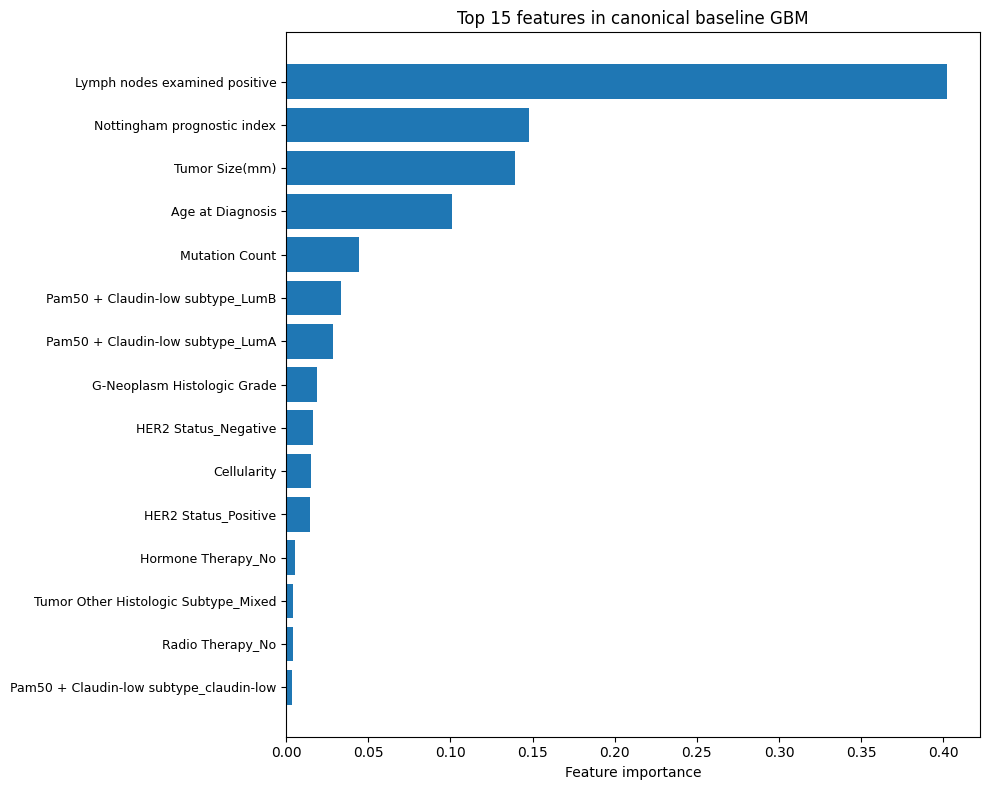


Saved figure to results/figures/baseline_feature_importance.png


In [12]:
# === Additional analysis: feature importance from the canonical baseline ===
# Useful context for the memo's discussion of which features actually drive predictions

import matplotlib.pyplot as plt

importances = pd.Series(gbm_full.feature_importances_, index=X_full.columns)
importances = importances.sort_values(ascending=False)

print("Top 15 features by GBM importance (canonical baseline):")
for feat, imp in importances.head(15).items():
    print(f"  {imp:.3f}  {feat}")

# Save as figure for the memo
fig, ax = plt.subplots(figsize=(10, 8))
top_15 = importances.head(15)
ax.barh(range(len(top_15)), top_15.values[::-1])
ax.set_yticks(range(len(top_15)))
ax.set_yticklabels(top_15.index[::-1], fontsize=9)
ax.set_xlabel('Feature importance')
ax.set_title('Top 15 features in canonical baseline GBM')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / 'baseline_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved figure to results/figures/baseline_feature_importance.png")

## Phase 2 Summary: Baselines

### Headline numbers

| Configuration | CV Acc ± std | Test Acc | Test Recall | Test F1 |
|---|---|---|---|---|
| GBM (chapter-faithful, with outcome-adjacent) | 0.783 ± 0.021 | 0.769 | 0.631 | 0.689 |
| GBM (chapter's 6 features, no outcome-adjacent) | 0.612 ± 0.014 | 0.609 | 0.250 | 0.342 |
| **GBM (full 18 features) — canonical comparison anchor** | **0.640 ± 0.029** | **0.665** | **0.344** | **0.455** |
| LR (full 18 features) | 0.654 ± 0.017 | 0.662 | 0.319 | 0.434 |
| LR (chapter's 6 features) | 0.611 ± 0.023 | 0.602 | 0.219 | 0.308 |
| GBM (recall-tuned, full features) | 0.436 (CV recall) | 0.602 | 0.394 | 0.445 |

### Key findings for the memo

**1. The chapter's 0.859 was not reproducible.** Closest result with chapter's setup including outcome-adjacent feature: 0.792 (across five random seeds). Persistent gap of 7-9 points. The chapter's confusion matrix sums to 164 patients vs our 394, suggesting they used a smaller test set than ours, possibly via different splitting or post-hoc filtering.

**2. The outcome-adjacent feature was carrying most of the chapter's predictive signal.** Removing `Relapse Free Status (Months)` drops chapter-faithful accuracy from 0.769 to 0.609 and recall from 0.631 to 0.250. This feature is defined in terms of when (and whether) recurrence occurred, which constitutes data leakage when used as a predictor.

**3. The chapter's six selected features are not a strong subset.** Using all 18 available predictors raises GBM accuracy from 0.609 to 0.665 (+5.6 points) and recall from 0.250 to 0.344 (+9.4 points). The chapter's union-of-six-methods feature selection appears to have been overly restrictive.

**4. Logistic regression matches GBM closely.** On the full feature set, LR achieves 0.662 vs GBM's 0.665 (within 1 point). The GBM's nonlinear capacity is providing minimal gain, suggesting the underlying problem is not strongly nonlinear and simpler models can compete on accuracy.

**5. Recall tuning produces a real but modest improvement at a cost.** GridSearchCV tuned for recall yields 0.394 recall vs 0.344 for the default GBM (+5 points), but accuracy drops from 0.665 to 0.602 (-6.3 points). This is the expected trade-off when shifting from accuracy to recall optimization.

### Comparison anchor for downstream phases

NSAI methods will be compared primarily against the **full-feature GBM (0.665 / 0.344 recall)**, with the chapter's six-feature configuration reported alongside as a secondary reference. This change from the original plan reflects that NSAI methods like GOSDT do their own feature selection — comparing GOSDT (which sees all features and chooses) to a baseline given only six is not a fair comparison.

### Methodological notes for the memo

- We constructed three GBM baselines representing different choices: chapter-faithful, chapter's-6-features-without-outcome-adjacency, and full-features. We did not produce a single "canonical" baseline by editorializing on the chapter's choices; we report all three and explain the comparison anchor we chose for NSAI evaluation.
- The 7-9 point gap to the chapter's reported 0.859 is documented but not resolved. We note possible explanations rather than asserting a single one.
- Both GBMs (canonical and chapter) are saved as pickles for use by Phase 5 (mimic trees) and Phase 7 (SHAP).

### Files produced

- `results/tables/baselines.csv` — comparison table with all six baseline configurations
- `results/models/canonical_gbm.pkl` — full-feature GBM (the comparison anchor)
- `results/models/chapter_gbm.pkl` — chapter's six-feature GBM (secondary reference)